In [1]:
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import scanpy as sc
import torch
from torch.utils.data import DataLoader, TensorDataset
from vae_v1 import *

Seed set to 42


In [2]:
data = sc.read_h5ad("../data/adata_72h-1_processed_6_1_25.h5ad")
x = data.obsm["X_diffmap"][:, 1:]

In [3]:
# Convert numpy array to tensor and get dimensions
x_tensor = torch.FloatTensor(x)
print(f"Data shape: {x_tensor.shape}")
input_dim = x_tensor.shape[1]

# Create dataset and dataloader
dataset = TensorDataset(x_tensor, torch.zeros(x_tensor.shape[0]))  # dummy labels
dataloader = DataLoader(dataset, batch_size=250, shuffle=True)

# Initialize model with correct dimensions
encoder = Encoder(input_dim=input_dim, hidden_dim=16 * 60, latent_dim=15)
decoder = Decoder(output_dim=input_dim, hidden_dim=16 * 60, latent_dim=15)
model = VAE(encoder, decoder)

# Initialize trainer and fit
trainer = pl.Trainer(accelerator="gpu", max_epochs=2000)
trainer.fit(model, dataloader)

Data shape: torch.Size([1000, 14])


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/stanfish/Git/vae/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch

Epoch 1999: 100%|██████████| 4/4 [00:00<00:00, 30.00it/s, v_num=42, loss=-47.1]

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 1999: 100%|██████████| 4/4 [00:00<00:00, 17.83it/s, v_num=42, loss=-47.1]


In [4]:
out = [i.detach().numpy() for i in model(x_tensor)]

[array([[ 0.00377066,  0.02648902, -0.0370552 , ..., -0.01369986,
          0.01232488,  0.00455906],
        [ 0.05780328, -0.03293756,  0.01002193, ..., -0.01650564,
          0.00566454,  0.02028546],
        [ 0.0145395 ,  0.01013048, -0.03218842, ..., -0.00651216,
          0.0099715 ,  0.00642922],
        ...,
        [-0.01113926, -0.01643869,  0.00331722, ..., -0.01745174,
         -0.00096231,  0.00853807],
        [-0.02548199, -0.00655591,  0.02046176, ..., -0.0048454 ,
          0.004087  ,  0.00133614],
        [ 0.05053356, -0.02986904,  0.01034722, ..., -0.00042793,
          0.00905133,  0.00980597]], dtype=float32),
 array([[-8.646399 , -7.352606 , -7.0896997, ..., -8.752943 , -5.142136 ,
         -9.414879 ],
        [-8.38638  , -7.9987745, -9.651127 , ..., -5.4525824, -9.566942 ,
         -5.1553073],
        [-9.08433  , -7.815612 , -7.520007 , ..., -8.806509 , -6.0433846,
         -9.987669 ],
        ...,
        [-8.114349 , -7.156473 , -9.190505 , ..., -8.1327

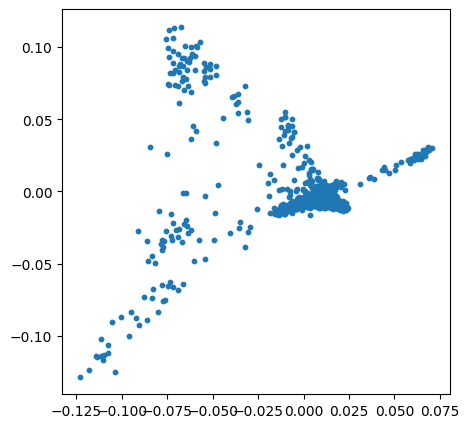

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# ax.scatter(x[:, 2], x[:, 3], s=10)
ax.scatter(out[0][:, 2], out[0][:, 3], s=10)

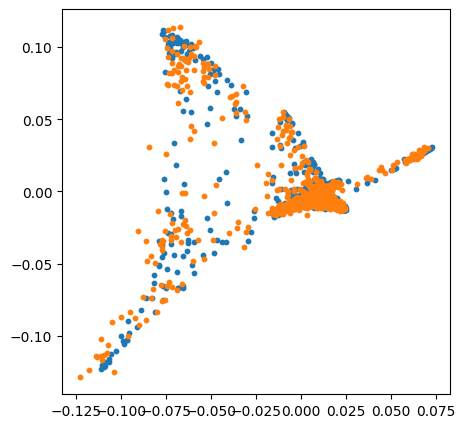

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(x[:, 2], x[:, 3], s=10)
ax.scatter(out[0][:, 2], out[0][:, 3], s=10)